# Full Dataset

## Imports

In [24]:
import pandas as pd
from prepare_data import *
from config import *
import numpy as np
import matplotlib.pyplot as plt
pd.set_option("display.max_columns", None)

## Cost

In [25]:
raw = pd.read_json(API_DATA_DIR / 'raw_responses' / '20261001-133048-gpt-5.6-terra.jsonl', lines=True)
raw = raw[['model', 'usage', 'batch_index']]

usage = pd.json_normalize(raw['usage'])
raw = pd.concat([raw.drop(columns='usage'), usage], axis=1)
raw.head()

,model,batch_index,completion_tokens,prompt_tokens,total_tokens,reasoning_tokens,cost,completion_tokens_details.accepted_prediction_tokens,completion_tokens_details.audio_tokens,completion_tokens_details.reasoning_tokens,completion_tokens_details.rejected_prediction_tokens,completion_tokens_details.text_tokens,completion_tokens_details.image_tokens,prompt_tokens_details.audio_tokens,prompt_tokens_details.cache_write_tokens,prompt_tokens_details.cached_tokens,prompt_tokens_details.image_tokens,prompt_tokens_details.text_tokens,prompt_tokens_details.video_tokens,prompt_tokens_details.cache_creation_tokens,cost_details.upstream_inference_cost,cost_details.upstream_inference_prompt_cost,cost_details.upstream_inference_completions_cost,cost_details.total_cost,cost_details.input_cost,cost_details.output_cost,cost_details.cached_input_cost,cost_details.cache_write_input_cost,cost_details.request_cost,cost_details.web_search_cost,cost_details.image_input_cost,cost_details.image_output_cost,cost_details.audio_input_cost
0,openai/gpt-5.6-terra,0,4868,105394,110262,3686,0.402503,None,0,3686,None,None,0,0,6598,0,0,None,0,6598.0,0.272503,0.214087,0.058416,0.402503,0.197592,0.058416,0.000000,0.016495,0,0.13,None,None,None
1,openai/gpt-5.6-terra,1,5019,116982,122001,3732,0.415497,None,0,3732,None,None,0,0,1427,5227,0,None,0,1427.0,0.285497,0.225269,0.060228,0.415497,0.220656,0.060228,0.001045,0.003567,0,0.13,None,None,None
2,openai/gpt-5.6-terra,2,5014,116480,121494,3792,0.424388,None,0,3792,None,None,0,0,1338,5227,0,None,0,1338.0,0.284388,0.224220,0.060168,0.424388,0.219830,0.060168,0.001045,0.003345,0,0.14,None,None,None
3,openai/gpt-5.6-terra,3,4414,107708,112122,3133,0.379669,None,0,3133,None,None,0,0,1387,5227,0,None,0,1387.0,0.259669,0.206701,0.052968,0.379669,0.202188,0.052968,0.001045,0.003467,0,0.12,None,None,None
4,openai/gpt-5.6-terra,4,5597,91022,96619,4299,0.340525,None,0,4299,None,None,0,0,1452,5227,0,None,0,1452.0,0.240525,0.173361,0.067164,0.340525,0.168686,0.067164,0.001045,0.003630,0,0.10,None,None,None


In [26]:
print(f"Model {raw.model.unique()[0]} cost ${round(float(raw.cost.sum()), 2)}")

Model openai/gpt-5.6-terra cost $55.79


In [27]:
df = pd.read_csv(API_DATA_DIR / 'responses' / '20261001-133048-gpt-5.6-terra.csv', usecols=['model', 'batch_index', 'answer'])
df['answer'] = df['answer'].apply(json.loads)
df_answer = pd.json_normalize(df['answer'])
df = df.drop(columns=['answer']).join(df_answer)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3125 entries, 0 to 3124
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   model         3125 non-null   str  
 1   batch_index   3125 non-null   int64
 2   id            3125 non-null   str  
 3   name          3125 non-null   str  
 4   hasFoundMenu  3125 non-null   bool 
 5   menuLink      3125 non-null   str  
 6   format        3125 non-null   str  
 7   source        3125 non-null   str  
dtypes: bool(1), int64(1), str(6)
memory usage: 525.7 KB


In [28]:
def summarize(raw, df):
    print(f"Model {raw.model.unique()[0]} cost ${round(float(raw.cost.sum()), 2)}")
    print(f"Found menus for {df.hasFoundMenu.sum()}/{len(df)} restaurants")
    n_links = df.menuLink.replace("", pd.NA).nunique()
    print(f"Unique menu links {n_links}/{len(df)} restaurants")


summarize(raw=raw, df=df)

Model openai/gpt-5.6-terra cost $55.79
Found menus for 2389/3125 restaurants
Unique menu links 2195/3125 restaurants


In [29]:
df.menuLink.replace("", pd.NA).value_counts().head(20)

menuLink
https://www.mcdonalds.com/dk/da-dk/vores-menu.html                                       21
https://jagger.dk/menu/                                                                  17
https://www.oliolipoke.dk/menu                                                           10
https://ottopizza.dk/menu/                                                               10
https://burgerking.dk/menu/view/drinks                                                   10
https://www.gasolinegrill.com/menu                                                        9
https://a.storyblok.com/f/286316/x/a7b0fc6a7f/sns-menu-dk-eng-2026-05-210x210-web.pdf     7
https://halifax.dk/menukort/                                                              6
https://picopizza.dk/menukort/                                                            6
https://www.wogk.dk/dk/menu                                                               5
https://www.groed.com/menu                                             

In [30]:
df.source.value_counts()

source
OFFICIAL_WEBSITE     1774
                      736
OTHER_THIRD_PARTY     319
WOLT                  245
UBEREATS               50
THE_FORK                1
Name: count, dtype: int64

In [31]:
df.format.value_counts()

format
HTML     1916
          736
PDF       388
JPEG       58
PNG        24
OTHER       3
Name: count, dtype: int64

## Cost

## Found Menu

In [32]:
df = df.drop('name', axis=1)
df_google = get_raw_data(RAW_DATA_DIR / 'copenhagen-bounds-full-raw.json')
df_google.head()

,id,name,formattedAddress,primaryType,googleMapsUri,websiteUri,businessStatus,rating,takeout,delivery,dineIn,servesBreakfast,servesLunch,servesDinner,servesBrunch,servesDessert,servesVegetarianFood,priceLevel,startPrice,endPrice,lat,lon
0,ChIJ6eXKTWdDUkYR7k5XjV6Ju-0,Ganløse Kro,"Bygaden 30, 3660 Stenløse, Denmark",restaurant,https://maps.google.com/?cid=17130436646825053...,http://ganlosekro.dk/,OPERATIONAL,4.4,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,NaN,PRICE_LEVEL_MODERATE,200,300,55.793494,12.262844
1,ChIJ21qBwtRDUkYRGBAxnmFfg10,Hjaltes Ganløse,"Bygaden 7, 3660 Stenløse, Denmark",restaurant,https://maps.google.com/?cid=67383343403468759...,http://www.hjaltesburesoe.dk/,OPERATIONAL,4.7,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,PRICE_LEVEL_MODERATE,100,200,55.791115,12.263354
3,ChIJV5-mcl5DUkYRbdj-CHc26vo,Ganløse Pizzaria & Grillbar,"Vestergade 1C, 3660 Stenløse, Denmark",pizza_restaurant,https://maps.google.com/?cid=18080323538912204...,http://ganløse-pizzaria.dk/,OPERATIONAL,4.1,1.0,NaN,1.0,NaN,1.0,1.0,0.0,NaN,NaN,NaN,1,100,55.791086,12.262935
6,ChIJIbl0IgBFUkYRU0k537QppSU,Café Kondi,"Farum Park 20, st. th, 3520 Farum, Denmark",restaurant,https://maps.google.com/?cid=27126202073765174...,NaN,OPERATIONAL,4.0,1.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55.817371,12.350827
7,ChIJt4pwV39FUkYRE1tcx-SMAqY,Furesø Madbank,"Farum Park 2, 3520 Farum, Denmark",restaurant,https://maps.google.com/?cid=11962278474474609...,NaN,OPERATIONAL,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55.815738,12.354581


In [33]:
df_joined = df_google.set_index('id').join(df.set_index('id'))
df_joined.head()

,name,formattedAddress,primaryType,googleMapsUri,websiteUri,businessStatus,rating,takeout,delivery,dineIn,servesBreakfast,servesLunch,servesDinner,servesBrunch,servesDessert,servesVegetarianFood,priceLevel,startPrice,endPrice,lat,lon,model,batch_index,hasFoundMenu,menuLink,format,source
id,,,,,,,,,,,,,,,,,,,,,,,,,,,
ChIJ6eXKTWdDUkYR7k5XjV6Ju-0,Ganløse Kro,"Bygaden 30, 3660 Stenløse, Denmark",restaurant,https://maps.google.com/?cid=17130436646825053...,http://ganlosekro.dk/,OPERATIONAL,4.4,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,NaN,PRICE_LEVEL_MODERATE,200,300,55.793494,12.262844,openai/gpt-5.6-terra,0,True,https://ganlosekro.dk/menukort/,HTML,OFFICIAL_WEBSITE
ChIJ21qBwtRDUkYRGBAxnmFfg10,Hjaltes Ganløse,"Bygaden 7, 3660 Stenløse, Denmark",restaurant,https://maps.google.com/?cid=67383343403468759...,http://www.hjaltesburesoe.dk/,OPERATIONAL,4.7,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,PRICE_LEVEL_MODERATE,100,200,55.791115,12.263354,openai/gpt-5.6-terra,0,True,https://hjaltesburesoe.dk/wp-content/uploads/2...,PDF,OFFICIAL_WEBSITE
ChIJV5-mcl5DUkYRbdj-CHc26vo,Ganløse Pizzaria & Grillbar,"Vestergade 1C, 3660 Stenløse, Denmark",pizza_restaurant,https://maps.google.com/?cid=18080323538912204...,http://ganløse-pizzaria.dk/,OPERATIONAL,4.1,1.0,NaN,1.0,NaN,1.0,1.0,0.0,NaN,NaN,NaN,1,100,55.791086,12.262935,openai/gpt-5.6-terra,0,False,,,
ChIJIbl0IgBFUkYRU0k537QppSU,Café Kondi,"Farum Park 20, st. th, 3520 Farum, Denmark",restaurant,https://maps.google.com/?cid=27126202073765174...,NaN,OPERATIONAL,4.0,1.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55.817371,12.350827,openai/gpt-5.6-terra,0,False,,,
ChIJt4pwV39FUkYRE1tcx-SMAqY,Furesø Madbank,"Farum Park 2, 3520 Farum, Denmark",restaurant,https://maps.google.com/?cid=11962278474474609...,NaN,OPERATIONAL,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55.815738,12.354581,openai/gpt-5.6-terra,0,False,,,


## Plot

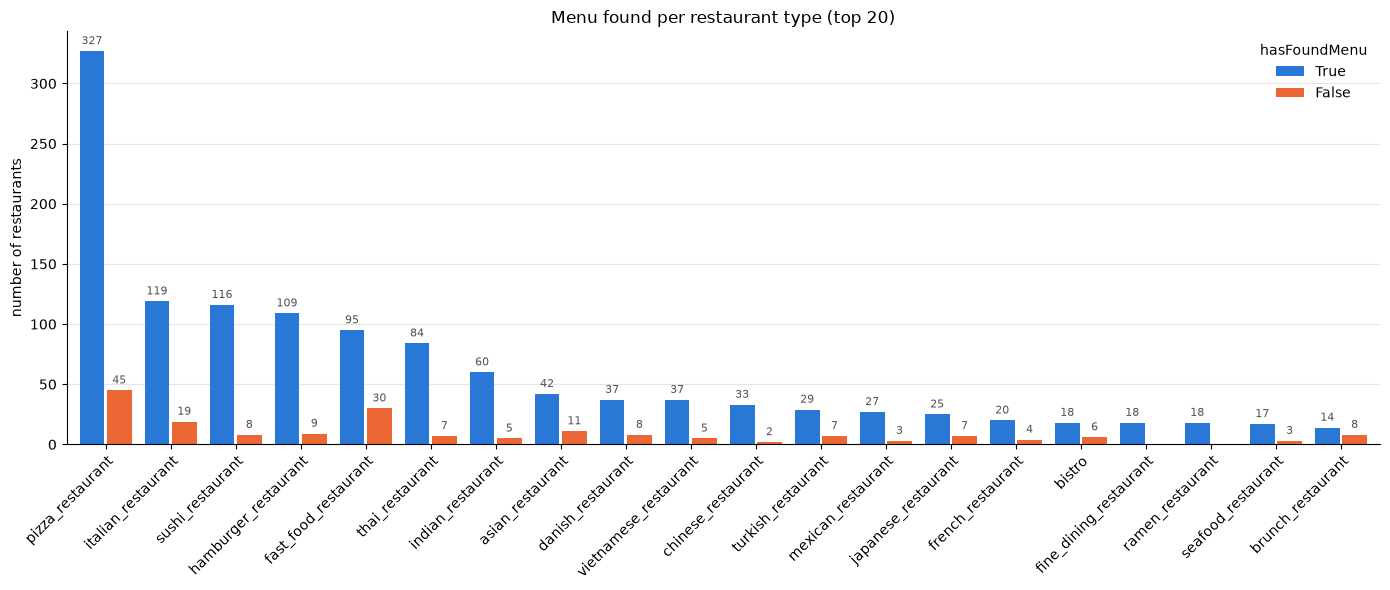

In [35]:
plot = pd.crosstab(df_joined["primaryType"], df_joined["hasFoundMenu"])
plot = plot.drop('restaurant')
# plot = plot.reindex(columns=[True, False], fill_value=0)   # keep both bars even if one value is missing
plot = plot.sort_values([True, False], ascending=False).head(20)

colors = {True: "#2a78d6", False: "#eb6834"}
x = np.arange(len(plot.index))
width = 0.38    # each bar of the pair
gap = 0.04      # space between the paired bars

fig, ax = plt.subplots(figsize=(0.6 * len(plot.index) + 2, 6))

for side, found in [(-1, True), (1, False)]:
    bars = ax.bar(x + side * (width + gap) / 2, plot[found], width=width,
                  color=colors[found], label=str(found))
    ax.bar_label(bars, labels=[v if v else "" for v in plot[found]],
                 padding=3, fontsize=8, color="#52514e")

ax.set_xticks(x)
ax.set_xticklabels(plot.index, rotation=45, ha="right", rotation_mode="anchor")
ax.set_xlim(-0.6, len(x) - 0.4)
ax.set_ylabel("number of restaurants")
ax.set_title("Menu found per restaurant type (top 20)")
ax.legend(title="hasFoundMenu", frameon=False, loc="upper right")
ax.grid(axis="y", color="#e5e5e5")
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

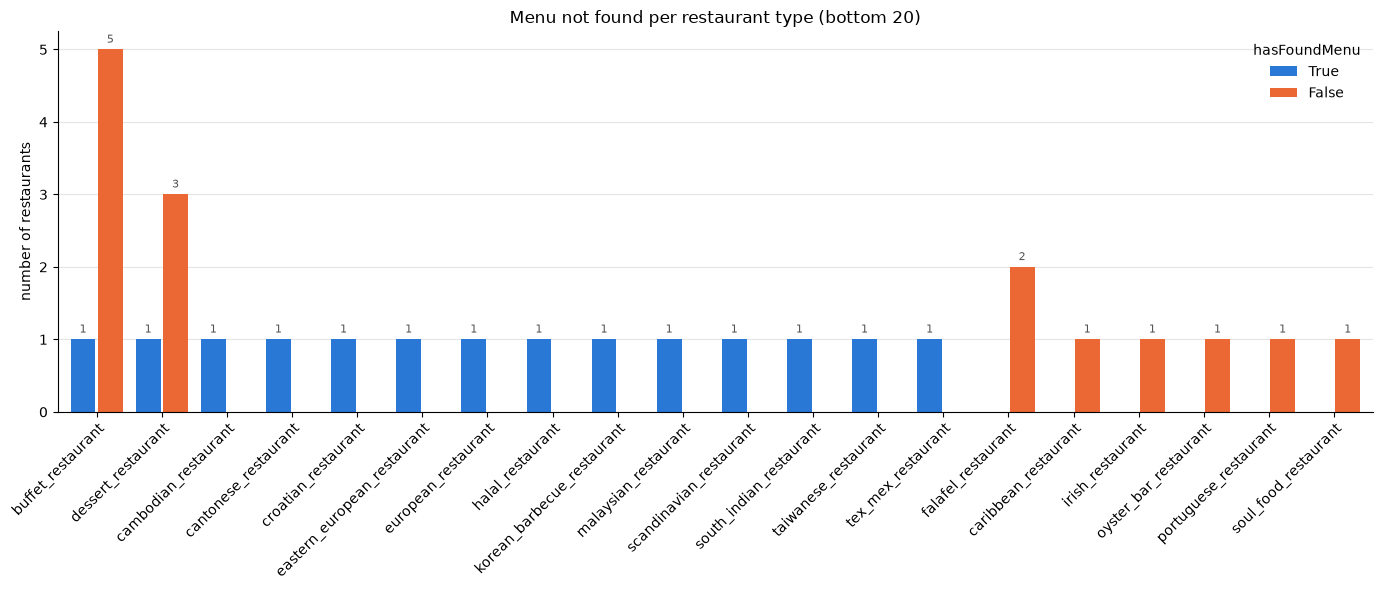

In [37]:
plot = pd.crosstab(df_joined["primaryType"], df_joined["hasFoundMenu"])
plot = plot.drop('restaurant')
# plot = plot.reindex(columns=[True, False], fill_value=0)   # keep both bars even if one value is missing
plot = plot.sort_values([True, False], ascending=False).tail(20)

colors = {True: "#2a78d6", False: "#eb6834"}
x = np.arange(len(plot.index))
width = 0.38    # each bar of the pair
gap = 0.04      # space between the paired bars

fig, ax = plt.subplots(figsize=(0.6 * len(plot.index) + 2, 6))

for side, found in [(-1, True), (1, False)]:
    bars = ax.bar(x + side * (width + gap) / 2, plot[found], width=width,
                  color=colors[found], label=str(found))
    ax.bar_label(bars, labels=[v if v else "" for v in plot[found]],
                 padding=3, fontsize=8, color="#52514e")

ax.set_xticks(x)
ax.set_xticklabels(plot.index, rotation=45, ha="right", rotation_mode="anchor")
ax.set_xlim(-0.6, len(x) - 0.4)
ax.set_ylabel("number of restaurants")
ax.set_title("Menu not found per restaurant type (bottom 20)")
ax.legend(title="hasFoundMenu", frameon=False, loc="upper right")
ax.grid(axis="y", color="#e5e5e5")
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

## Found Menu per Restaurant Type

In [38]:
found_per_type = pd.crosstab(df_joined["primaryType"], df_joined["hasFoundMenu"])
found_per_type["total"] = found_per_type.sum(axis=1)
found_per_type["found_pct"] = (100 * found_per_type[True] / found_per_type["total"]).round(1)

print(f"Overall found: {100 * df_joined.hasFoundMenu.mean():.1f}%")

# types where the model found fewer menus than it didn't find (or an even split)
found_per_type[found_per_type[False] >= found_per_type[True]].sort_values("total", ascending=False)

Overall found: 76.4%


hasFoundMenu,False,True,total,found_pct
primaryType,,,,
chicken_restaurant,4,3,7,42.9
breakfast_restaurant,5,1,6,16.7
buffet_restaurant,5,1,6,16.7
dessert_restaurant,3,1,4,25.0
western_restaurant,2,2,4,50.0
falafel_restaurant,2,0,2,0.0
caribbean_restaurant,1,0,1,0.0
irish_restaurant,1,0,1,0.0
oyster_bar_restaurant,1,0,1,0.0


In [39]:
# lowest found rate among types big enough to say something about
found_per_type[found_per_type.total >= 10].sort_values("found_pct").head(10)

hasFoundMenu,False,True,total,found_pct
primaryType,,,,
family_restaurant,8,9,17,52.9
brunch_restaurant,8,14,22,63.6
restaurant,490,969,1459,66.4
bagel_shop,3,9,12,75.0
bistro,6,18,24,75.0
fast_food_restaurant,30,95,125,76.0
japanese_restaurant,7,25,32,78.1
korean_restaurant,3,11,14,78.6
asian_restaurant,11,42,53,79.2


**Findings** (gpt-5.6-terra, 3125 restaurants, menu found for 76.4% overall)

- **10 types have more menus not found than found**: chicken (3/7 found), breakfast (1/6), buffet (1/6), dessert (1/4), falafel (0/2), and caribbean, irish, oyster_bar, portuguese and soul_food (0/1 each). `western_restaurant` is an even split (2/4). These are all tiny groups, so one restaurant either way flips the result -- they don't show that the type itself is hard.
- **Among types with at least 10 restaurants**, the lowest found rates are `family_restaurant` (53%, n=17), `brunch_restaurant` (64%, n=22) and the generic `restaurant` (66%, n=1459). Breakfast, brunch and family places all being low may point to cafés and small local places that don't publish a menu online -- not verified.
- The generic `restaurant` type is almost half the data and below average, so it pulls the overall rate down. The large specific types are at or above the average, so the model doesn't seem to struggle with any of them.
- This is only the *found* rate -- it says nothing about whether the found menus are correct.